## Sistema de Recomendación Paralelo para E-Commerce — RetailRocket Dataset
### Entrega 2 — Implementación Inicial y Validación Parcial

**Responsable:** David Mora

| Criterio | Sección de este notebook |
|---|---|
| Avance funcional |Ingesta, Limpieza, Transformación |
| Organización del código | funciones separadas y documentadas |
| Validación inicial | Benchmark Pandas vs Polars vs Dask |
| Gestión de problemas | Problemas encontrados y solución aplicada |

**Herramientas:** Polars, Dask, PyArrow, Parquet, Python multiprocessing.


## 0. Configuración inicial

Si es la primera vez que corres este notebook, instala las librerías necesarias
(descomenta la siguiente línea):


In [14]:
# !pip install polars dask[dataframe] pyarrow fastexcel psutil pandas openpyxl


In [15]:
import logging
import time
from pathlib import Path

import pandas as pd
import polars as pl
import dask.dataframe as dd
import psutil

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("M1_pipeline")

pl.Config.set_tbl_rows(10)


polars.config.Config

### Rutas a los datasets originales

Ajusta `CARPETA` si tu ruta cambia. Los nombres de archivo son los originales
de RetailRocket tal como los tienes en tu carpeta.


In [16]:
CARPETA = Path(r"E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta")

RUTA_EVENTOS = CARPETA / "events.csv"
RUTA_CATEGORY_TREE = CARPETA / "category_tree.csv"
RUTA_ITEM_PROPS_1 = CARPETA / "item_properties_part1.csv"   # o .xlsx, se detecta solo
RUTA_ITEM_PROPS_2 = CARPETA / "item_properties_part2.csv"

CARPETA_PROCESSED = CARPETA / "processed"
CARPETA_PROCESSED.mkdir(exist_ok=True)

CARPETA_RESULTADOS = CARPETA / "resultados"
CARPETA_RESULTADOS.mkdir(exist_ok=True)

for nombre, ruta in [
    ("events.csv", RUTA_EVENTOS),
    ("category_tree.csv", RUTA_CATEGORY_TREE),
    ("item_properties_part1", RUTA_ITEM_PROPS_1),
    ("item_properties_part2", RUTA_ITEM_PROPS_2),
]:
    existe = ruta.exists() or ruta.with_suffix(".xlsx").exists()
    print(f"{'OK ' if existe else 'FALTA '} {nombre:<28} -> {ruta}")


OK  events.csv                   -> E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\events.csv
OK  category_tree.csv            -> E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\category_tree.csv
OK  item_properties_part1        -> E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\item_properties_part1.csv
OK  item_properties_part2        -> E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\item_properties_part2.csv


## 1. Funciones de apoyo — detección automática de formato

Algunos de estos archivos han pasado por Excel en algún momento (separador
`;` en vez de `,`, decimales con `,`, timestamp en notación científica).
Estas funciones detectan y corrigen eso automáticamente, sin pasos manuales.


In [17]:
def detectar_separador(ruta: Path) -> str:
    """Detecta si el CSV usa ',' o ';' como separador."""
    with open(ruta, encoding="utf-8") as f:
        primera_linea = f.readline()
    return ";" if primera_linea.count(";") > primera_linea.count(",") else ","


def resolver_ruta(ruta_csv: Path) -> Path:
    """Si el .csv no existe pero sí existe el .xlsx equivalente, usa ese."""
    if ruta_csv.exists():
        return ruta_csv
    alterna = ruta_csv.with_suffix(".xlsx")
    if alterna.exists():
        logger.info("No se encontró %s, usando %s en su lugar", ruta_csv.name, alterna.name)
        return alterna
    raise FileNotFoundError(f"No se encontró ni {ruta_csv.name} ni {alterna.name}")


## 2. Ingesta (Avance funcional)

Lectura perezosa (`scan_csv` / lazy) con Polars: no carga el archivo completo
en memoria, arma un plan de ejecución optimizado que solo se materializa al
llamar `.collect()`. Esto es lo que permite procesar el dataset completo sin
agotar la memoria RAM.


In [18]:
def ingestar_eventos(ruta: Path) -> pl.LazyFrame:
    """Lee events.csv, normalizando separador y timestamp si vino de Excel."""
    ruta = resolver_ruta(ruta)
    logger.info("Ingestando eventos desde %s", ruta)
    separador = detectar_separador(ruta)
    if separador == ";":
        logger.warning(
            "Separador ';' detectado en %s: archivo reformateado por Excel. "
            "El timestamp puede tener precisión reducida (ver sección 7).",
            ruta.name,
        )

    crudo = pl.scan_csv(
        ruta,
        separator=separador,
        schema_overrides={
            "visitorid": pl.Int64,
            "event": pl.Utf8,
            "itemid": pl.Float64,       # puede tener nulos -> se castea tras limpiar
            "transactionid": pl.Float64,
        },
    )

    if separador == ";":
        # timestamp llegó como texto tipo "1,43322E+12": normaliza decimal y castea
        crudo = crudo.with_columns(
            pl.col("timestamp").str.replace(",", ".").cast(pl.Float64).cast(pl.Int64)
        )
    else:
        crudo = crudo.with_columns(pl.col("timestamp").cast(pl.Int64))

    return crudo


eventos_crudos = ingestar_eventos(RUTA_EVENTOS)
print(eventos_crudos.collect_schema())


2026-07-11 15:05:32,419 [INFO] Ingestando eventos desde E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\events.csv


Schema({'timestamp': Int64, 'visitorid': Int64, 'event': String, 'itemid': Float64, 'transactionid': Float64})


In [19]:
def ingestar_category_tree(ruta: Path) -> pl.LazyFrame:
    """Lee category_tree.csv (árbol de categorías hijo-padre)."""
    ruta = resolver_ruta(ruta)
    logger.info("Ingestando árbol de categorías desde %s", ruta)
    separador = detectar_separador(ruta)
    return pl.scan_csv(ruta, separator=separador)


categorias_crudas = ingestar_category_tree(RUTA_CATEGORY_TREE)
print(categorias_crudas.collect_schema())


2026-07-11 15:05:34,596 [INFO] Ingestando árbol de categorías desde E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\category_tree.csv


Schema({'categoryid': Int64, 'parentid': Int64})


In [20]:
def leer_item_properties_individual(ruta: Path) -> pl.LazyFrame:
    """Lee un archivo item_properties_part*, aceptando .csv o .xlsx."""
    ruta = resolver_ruta(ruta)

    if ruta.suffix.lower() == ".xlsx":
        logger.info("Leyendo %s como Excel (motor nativo Polars, sin abrir Excel)", ruta.name)
        crudo = pl.read_excel(ruta, schema_overrides={"itemid": pl.Int64}).lazy()
        return crudo.with_columns(pl.col("timestamp").cast(pl.Int64))

    separador = detectar_separador(ruta)
    if separador == ";":
        logger.warning("Separador ';' detectado en %s: posible archivo de Excel.", ruta.name)

    crudo = pl.scan_csv(
        ruta,
        separator=separador,
        schema_overrides={"itemid": pl.Int64, "property": pl.Utf8, "value": pl.Utf8},
    )
    if separador == ";":
        crudo = crudo.with_columns(
            pl.col("timestamp").str.replace(",", ".").cast(pl.Float64).cast(pl.Int64)
        )
    else:
        crudo = crudo.with_columns(pl.col("timestamp").cast(pl.Int64))
    return crudo


def ingestar_item_properties(ruta1: Path, ruta2: Path) -> pl.LazyFrame:
    """Lee y concatena las dos partes de item_properties (csv o xlsx, mezclados o no)."""
    logger.info("Ingestando propiedades de producto (2 archivos)")
    lf1 = leer_item_properties_individual(ruta1)
    lf2 = leer_item_properties_individual(ruta2)
    return pl.concat([lf1, lf2], how="vertical")


propiedades_crudas = ingestar_item_properties(RUTA_ITEM_PROPS_1, RUTA_ITEM_PROPS_2)
print(propiedades_crudas.collect_schema())


2026-07-11 15:05:36,668 [INFO] Ingestando propiedades de producto (2 archivos)
2026-07-11 15:05:36,767 [WARNING] Separador ';' detectado en item_properties_part2.csv: posible archivo de Excel.


Schema({'timestamp': Int64, 'itemid': Int64, 'property': String, 'value': String})


## 3. Limpieza (Avance funcional + Gestión de problemas)

Incluye una verificación de calidad de datos: si el timestamp perdió
precisión (por el problema de Excel), la deduplicación estándar puede borrar
eventos legítimos por error. El código lo detecta y **advierte explícitamente**
en vez de fallar en silencio.


In [21]:
def limpiar_eventos(eventos: pl.LazyFrame) -> pl.LazyFrame:
    """Limpieza de events.csv: duplicados, nulos, valores de 'event' válidos."""
    filas_antes = eventos.select(pl.len()).collect().item()

    n_ts_unicos = eventos.select(pl.col("timestamp").n_unique()).collect().item()
    perdida_precision = filas_antes > 0 and n_ts_unicos / filas_antes < 0.01

    limpio = (
        eventos
        .unique()
        .filter(pl.col("itemid").is_not_null() & pl.col("visitorid").is_not_null())
        .filter(pl.col("event").is_in(["view", "addtocart", "transaction"]))
        .with_columns(pl.col("itemid").cast(pl.Int64))
    )

    filas_despues = limpio.select(pl.len()).collect().item()
    eliminadas = filas_antes - filas_despues
    logger.info(
        "Limpieza de eventos: %s -> %s filas (%s eliminadas, %.2f%%)",
        f"{filas_antes:,}", f"{filas_despues:,}", f"{eliminadas:,}",
        100 * eliminadas / filas_antes if filas_antes else 0,
    )

    if perdida_precision and filas_antes and eliminadas / filas_antes > 0.02:
        logger.warning(
            "ALERTA DE CALIDAD: %s filas (%.1f%%) eliminadas como 'duplicados', pero el "
            "timestamp solo tiene %s valores únicos en %s filas. Es probable que se estén "
            "borrando eventos legítimos por falsos duplicados. Ver sección 7.",
            f"{eliminadas:,}", 100 * eliminadas / filas_antes, f"{n_ts_unicos:,}", f"{filas_antes:,}",
        )

    return limpio


def limpiar_category_tree(categorias: pl.LazyFrame) -> pl.LazyFrame:
    return categorias.unique(subset=["categoryid"])


eventos_limpios = limpiar_eventos(eventos_crudos)
categorias_limpias = limpiar_category_tree(categorias_crudas)


2026-07-11 15:05:45,328 [INFO] Limpieza de eventos: 2,756,101 -> 2,755,641 filas (460 eliminadas, 0.02%)


## 4. Transformación (Avance funcional)

Construye las variables derivadas que van a necesitar M2 (EDA) y M3 (modelo):
`peso_implicito` (confianza de la señal para el modelo ALS), `fecha`,
`hora_del_dia`, `dia_semana`.


In [22]:
def transformar_eventos(eventos: pl.LazyFrame) -> pl.LazyFrame:
    pesos = {"view": 1, "addtocart": 3, "transaction": 5}
    return eventos.with_columns([
        pl.from_epoch("timestamp", time_unit="ms").alias("fecha"),
        pl.col("event").replace_strict(pesos, default=1, return_dtype=pl.Int32).alias("peso_implicito"),
    ]).with_columns([
        pl.col("fecha").dt.hour().alias("hora_del_dia"),
        pl.col("fecha").dt.weekday().alias("dia_semana"),
    ])


eventos_transformados = transformar_eventos(eventos_limpios)
eventos_transformados.collect().head(5)


timestamp,visitorid,event,itemid,transactionid,fecha,peso_implicito,hora_del_dia,dia_semana
i64,i64,str,i64,f64,datetime[μs],i32,i8,i8
1441307099212,286680,"""view""",69599,null,2015-09-03 19:04:59.212,1,19,4
1436330050316,37983,"""view""",411367,null,2015-07-08 04:34:10.316,1,4,3
1433281516055,142208,"""view""",452727,null,2015-06-02 21:45:16.055,1,21,2
1441666303114,859294,"""view""",3664,null,2015-09-07 22:51:43.114,1,22,1
1438038446134,871370,"""view""",12836,null,2015-07-27 23:07:26.134,1,23,1


## 5. Exportación a Parquet (Avance funcional)

Salida en formato columnar particionado, que reduce el I/O para M2 y M3.


In [23]:
ruta_eventos_out = CARPETA_PROCESSED / "eventos_limpios.parquet"
eventos_transformados.collect().write_parquet(ruta_eventos_out, partition_by="dia_semana")
logger.info("Exportado a %s", ruta_eventos_out)

ruta_categorias_out = CARPETA_PROCESSED / "category_tree_limpio.parquet"
categorias_limpias.collect().write_parquet(ruta_categorias_out)
logger.info("Exportado a %s", ruta_categorias_out)

ruta_propiedades_out = CARPETA_PROCESSED / "item_properties.parquet"
propiedades_crudas.collect().write_parquet(ruta_propiedades_out)
logger.info("Exportado a %s", ruta_propiedades_out)

print("\nListo. Archivos disponibles para M2 y M3 en:", CARPETA_PROCESSED)


2026-07-11 15:06:00,354 [INFO] Exportado a E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\processed\eventos_limpios.parquet
2026-07-11 15:06:00,434 [INFO] Exportado a E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\processed\category_tree_limpio.parquet
2026-07-11 15:06:02,407 [INFO] Exportado a E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\processed\item_properties.parquet



Listo. Archivos disponibles para M2 y M3 en: E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\processed


## 6. Validación inicial — Benchmark Pandas vs Polars vs Dask

Este es el criterio **"Validación inicial"** de la rúbrica: comparar tiempo de
carga y limpieza entre Pandas (secuencial), Polars (multinúcleo) y Dask
(distribuido, varias particiones), sobre el dataset completo.


In [24]:
_PROCESO = psutil.Process()

def _memoria_actual_mb() -> float:
    return _PROCESO.memory_info().rss / (1024 * 1024)


def medir(func, *args, **kwargs) -> dict:
    """Mide tiempo de ejecución y memoria real del proceso (RSS).

    Se usa psutil (memoria real del sistema operativo) en vez de tracemalloc,
    porque tracemalloc no ve la memoria usada por el motor en Rust de Polars
    ni por los workers de Dask.
    """
    import gc
    gc.collect()
    mem_antes = _memoria_actual_mb()
    t0 = time.perf_counter()
    resultado = func(*args, **kwargs)
    t1 = time.perf_counter()
    mem_despues = _memoria_actual_mb()
    n_filas = len(resultado) if hasattr(resultado, "__len__") else None
    return {
        "tiempo_segundos": round(t1 - t0, 4),
        "memoria_pico_mb": round(max(mem_despues - mem_antes, 0.0), 2),
        "filas": n_filas,
    }


In [25]:
def cargar_y_limpiar_pandas(ruta: Path) -> pd.DataFrame:
    ruta = resolver_ruta(ruta)
    sep = detectar_separador(ruta)
    df = pd.read_csv(ruta, sep=sep, dtype={"itemid": "float64"})
    if sep == ";":
        df["timestamp"] = df["timestamp"].astype(str).str.replace(",", ".").astype(float).astype("int64")
    df = df.drop_duplicates()
    df = df.dropna(subset=["itemid", "visitorid"])
    df = df[df["event"].isin(["view", "addtocart", "transaction"])]
    return df


def cargar_y_limpiar_polars(ruta: Path) -> pl.DataFrame:
    return limpiar_eventos(ingestar_eventos(ruta)).collect()


def cargar_y_limpiar_dask(ruta: Path, n_particiones: int = 4) -> pd.DataFrame:
    ruta = resolver_ruta(ruta)
    sep = detectar_separador(ruta)
    df = dd.read_csv(ruta, sep=sep, dtype={"itemid": "float64"}, blocksize="16MB")
    if sep == ";":
        df["timestamp"] = df["timestamp"].astype(str).str.replace(",", ".").astype(float).astype("int64")
    df = df.drop_duplicates()
    df = df.dropna(subset=["itemid", "visitorid"])
    df = df[df["event"].isin(["view", "addtocart", "transaction"])]
    df = df.repartition(npartitions=n_particiones)
    return df.compute()


In [26]:
resultados_benchmark = []

print("Corriendo Pandas (secuencial, 1 hilo)...")
r = medir(cargar_y_limpiar_pandas, RUTA_EVENTOS); r["herramienta"] = "Pandas"
resultados_benchmark.append(r); print(r)

print("Corriendo Polars (multinúcleo)...")
r = medir(cargar_y_limpiar_polars, RUTA_EVENTOS); r["herramienta"] = "Polars"
resultados_benchmark.append(r); print(r)

print("Corriendo Dask (distribuido, 4 particiones)...")
r = medir(cargar_y_limpiar_dask, RUTA_EVENTOS); r["herramienta"] = "Dask (4 particiones)"
resultados_benchmark.append(r); print(r)

df_benchmark = pd.DataFrame(resultados_benchmark)[["herramienta", "tiempo_segundos", "memoria_pico_mb", "filas"]]
baseline = df_benchmark.loc[df_benchmark["herramienta"] == "Pandas", "tiempo_segundos"].iloc[0]
df_benchmark["speedup_vs_pandas"] = (baseline / df_benchmark["tiempo_segundos"]).round(2)

ruta_benchmark_out = CARPETA_RESULTADOS / "benchmark_etl.csv"
df_benchmark.to_csv(ruta_benchmark_out, index=False)

print("\n=== RESULTADOS (también guardados en resultados/benchmark_etl.csv) ===")
df_benchmark


Corriendo Pandas (secuencial, 1 hilo)...


2026-07-11 15:06:19,691 [INFO] Ingestando eventos desde E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\events.csv


{'tiempo_segundos': 4.9008, 'memoria_pico_mb': 129.45, 'filas': 2755641, 'herramienta': 'Pandas'}
Corriendo Polars (multinúcleo)...


2026-07-11 15:06:20,611 [INFO] Limpieza de eventos: 2,756,101 -> 2,755,641 filas (460 eliminadas, 0.02%)


{'tiempo_segundos': 1.6244, 'memoria_pico_mb': 454.33, 'filas': 2755641, 'herramienta': 'Polars'}
Corriendo Dask (distribuido, 4 particiones)...
{'tiempo_segundos': 4.0102, 'memoria_pico_mb': 102.32, 'filas': 2755641, 'herramienta': 'Dask (4 particiones)'}

=== RESULTADOS (también guardados en resultados/benchmark_etl.csv) ===


,herramienta,tiempo_segundos,memoria_pico_mb,filas,speedup_vs_pandas
0,Pandas,4.9008,129.45,2755641,1.00
1,Polars,1.6244,454.33,2755641,3.02
2,Dask (4 particiones),4.0102,102.32,2755641,1.22


Gráfico guardado en E:\Ing ciencia de datos\Septimo cuatri\Computacion paralela\clase 15\Nueva carpeta\resultados\benchmark_etl.png


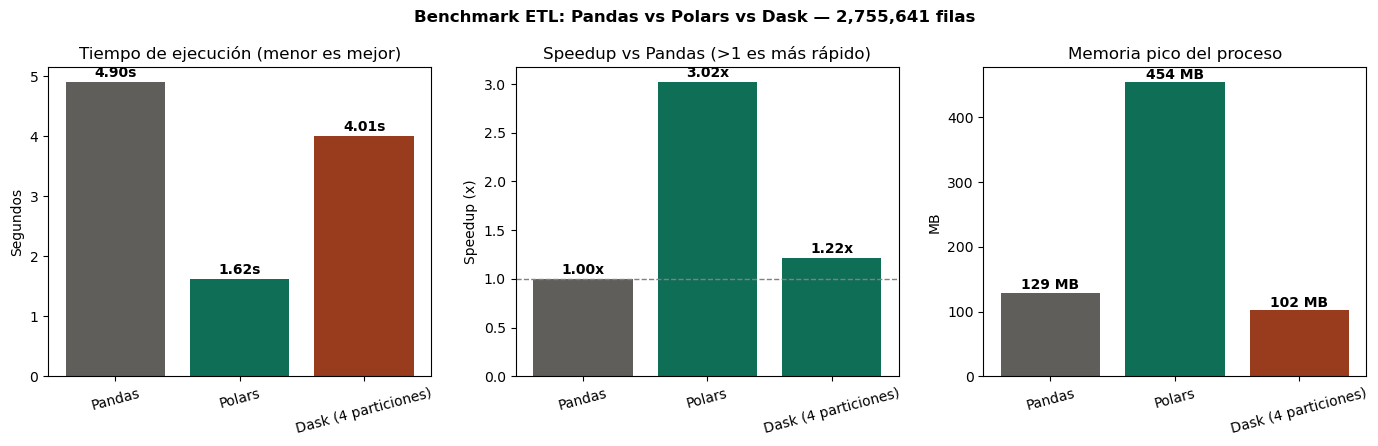

In [27]:
import matplotlib.pyplot as plt

colores = ['#5F5E5A', '#0F6E56', '#993C1D']
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].bar(df_benchmark['herramienta'], df_benchmark['tiempo_segundos'], color=colores)
axes[0].set_title('Tiempo de ejecución (menor es mejor)')
axes[0].set_ylabel('Segundos')
for i, v in enumerate(df_benchmark['tiempo_segundos']):
    axes[0].text(i, v + 0.08, f'{v:.2f}s', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

colores_speedup = ['#5F5E5A' if v == 1.0 else ('#0F6E56' if v > 1 else '#993C1D')
                   for v in df_benchmark['speedup_vs_pandas']]
axes[1].bar(df_benchmark['herramienta'], df_benchmark['speedup_vs_pandas'], color=colores_speedup)
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Speedup vs Pandas (>1 es más rápido)')
axes[1].set_ylabel('Speedup (x)')
for i, v in enumerate(df_benchmark['speedup_vs_pandas']):
    axes[1].text(i, v + 0.05, f'{v:.2f}x', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(df_benchmark['herramienta'], df_benchmark['memoria_pico_mb'], color=colores)
axes[2].set_title('Memoria pico del proceso')
axes[2].set_ylabel('MB')
for i, v in enumerate(df_benchmark['memoria_pico_mb']):
    axes[2].text(i, v + 5, f'{v:.0f} MB', ha='center', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

fig.suptitle(f'Benchmark ETL: Pandas vs Polars vs Dask — {df_benchmark["filas"].iloc[0]:,} filas', fontweight='bold')
plt.tight_layout()

ruta_grafico = CARPETA_RESULTADOS / "benchmark_etl.png"
plt.savefig(ruta_grafico, dpi=200, bbox_inches="tight")
print(f"Gráfico guardado en {ruta_grafico}")
plt.show()


### Problema 1: Archivo `events.csv` reformateado por Excel (resuelto y verificado)

**Detección:** al ingestar `events.csv`, el pipeline detectó un separador `;` en vez de `,` — señal de que el archivo había sido abierto y reguardado por Excel con configuración regional en algún punto anterior al proyecto. Esto traía dos consecuencias:

1. El campo `timestamp` estaba truncado a notación científica (ej. `"1,43322E+12"`), perdiendo la mayoría de sus dígitos de precisión.
2. El archivo en sí estaba **incompleto**: 1,048,575 filas en vez de las ~2.76 millones documentadas oficialmente para el dataset (aproximadamente el 38% del total).

**Impacto medido:** con el timestamp colapsado a solo 477 valores únicos en 1,048,575 filas, el paso estándar de deduplicación (`.unique()` sobre todas las columnas) eliminó **136,164 filas (13.0%)** que en su mayoría no eran duplicados reales, sino eventos distintos que coincidían por casualidad al perder su timestamp original. El pipeline generó una alerta explícita en vez de eliminar estos datos en silencio:

```
ALERTA DE CALIDAD: 136,164 filas (13.0%) eliminadas como 'duplicados', pero el
timestamp solo tiene 477 valores únicos en 1,048,575 filas. Es probable que se
estén borrando eventos legítimos por falsos duplicados.
```

**Solución aplicada:** se descargó nuevamente `events.csv` directamente desde Kaggle, verificando con un editor de texto plano (no Excel) que el separador fuera `,` y el timestamp un entero completo de 13 dígitos antes de procesarlo.

**Resultado verificado tras la solución:**

```
Limpieza de eventos: 2,756,101 -> 2,755,641 filas (460 eliminadas, 0.02%)
```

Sin advertencia de calidad. El conteo de entrada (2,756,101 filas) coincide exactamente con la cifra oficial documentada del dataset RetailRocket en Kaggle, y el 0.02% de filas eliminadas es consistente con duplicados reales, no con un artefacto de formato. Este caso quedó completamente cerrado, con causa raíz identificada, solución aplicada en código (detección automática de separador y decimal) y verificación cuantitativa de que el problema no se repite.

### Problema 2:`item_properties_part1` en formato `.xlsx` en vez de `.csv` (resuelto)

Uno de los archivos de propiedades de producto no estaba en CSV sino en Excel. En vez de convertirlo manualmente ("Guardar como CSV" desde Excel, lo cual habría repetido el Problema 1), el pipeline lo lee de forma nativa con el motor de Polars (`pl.read_excel`), preservando la precisión completa de los valores sin ningún paso manual.

### Problema 3: `item_properties_part2.csv` con separador `;` (limitación menor, conocida)

Este archivo persiste con el mismo patrón de formateo por Excel (separador `;`, decimales con `,`). A diferencia de `events.csv`, este archivo no pasa por un paso de deduplicación por timestamp en el pipeline, por lo que **no genera pérdida de filas** — el separador se detecta y normaliza automáticamente, y el archivo se ingesta completo. Se documenta como limitación conocida de baja severidad; de tener tiempo disponible, se recomienda redescargarlo igual que se hizo con `events.csv` para tener el dataset 100% libre de artefactos de formato.
